# Depression Prediction Model: Multi-Dataset Analysis

## Project Overview

This notebook presents a comprehensive machine learning pipeline to predict depression risk using data from two independent sources. 

### Key Objectives
- **Combine two datasets** with the same conceptual features but different measurement scales
  - Dataset A: 10-point GPA scale, specific sleep duration ranges
  - Dataset B: 4-point GPA scale, different sleep hour ranges
- **Unified Feature Space**: After careful renaming and standardization, both datasets share the same feature set
- **Depression Prediction**: Build a predictive model to identify students at risk of depression (Binary: 0=No, 1=Yes)
- **Risk Stratification**: Classify predictions into risk levels:
  - **Low Risk**: Low probability of depression
  - **Medium Risk**: Moderate probability of depression  
  - **High Risk**: High probability of depression

### Methodology
This analysis includes comprehensive exploratory data analysis, statistical testing, feature engineering, and model development with proper handling of scale differences between datasets.

In [59]:
import pandas as pd
import numpy as np
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Load Data

Load datasets A and B from the data directory.

In [60]:
# Load datasets
data_path = Path('../data')

ds_a = pd.read_csv(data_path / 'ds_a.csv')
ds_b = pd.read_csv(data_path / 'ds_b.csv')

print("✓ Dataset A loaded")
print("✓ Dataset B loaded")

✓ Dataset A loaded
✓ Dataset B loaded


## 2. Data Profiling

Basic profiling and exploratory analysis of both datasets.

### Dataset A

In [61]:
print("Dataset A - Shape:", ds_a.shape)
print("\nFirst few rows:")
print(ds_a.head())

print("\n" + "="*50)
print("Dataset A - Info:")
print("="*50)
print(ds_a.info())

print("\n" + "="*50)
print("Dataset A - Statistical Summary:")
print("="*50)
print(ds_a.describe())

Dataset A - Shape: (27901, 5)

First few rows:
   CGPA  Sleep Duration  Work/Study Hours  Academic Pressure  Depression
0  8.97             5.5                 3                  5           1
1  5.90             5.5                 3                  2           0
2  7.03             4.5                 9                  3           0
3  5.59             7.5                 4                  3           1
4  8.13             5.5                 1                  4           0

Dataset A - Info:
<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CGPA               27901 non-null  float64
 1   Sleep Duration     27901 non-null  float64
 2   Work/Study Hours   27901 non-null  int64  
 3   Academic Pressure  27901 non-null  int64  
 4   Depression         27901 non-null  int64  
dtypes: float64(2), int64(3)
memory usage: 1.1 MB
None

Dataset

In [62]:
print("Missing values in Dataset A:")
print(ds_a.isnull().sum())
print(f"\nTotal missing: {ds_a.isnull().sum().sum()}")

Missing values in Dataset A:
CGPA                 0
Sleep Duration       0
Work/Study Hours     0
Academic Pressure    0
Depression           0
dtype: int64

Total missing: 0


### Dataset B

In [63]:
print("Dataset B - Shape:", ds_b.shape)
print("\nFirst few rows:")
print(ds_b.head())

print("\n" + "="*50)
print("Dataset B - Info:")
print("="*50)
print(ds_b.info())

print("\n" + "="*50)
print("Dataset B - Statistical Summary:")
print("="*50)
print(ds_b.describe())

Dataset B - Shape: (100000, 5)

First few rows:
   CGPA  Sleep_Duration  Study_Hours  Stress_Level  Depression
0  3.50             7.3          3.3             5           0
1  2.72             5.5          7.2             2           0
2  3.01             5.4          2.3             3           0
3  3.63             8.1          2.0             3           0
4  3.14             6.8          2.6             6           0

Dataset B - Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CGPA            100000 non-null  float64
 1   Sleep_Duration  100000 non-null  float64
 2   Study_Hours     100000 non-null  float64
 3   Stress_Level    100000 non-null  int64  
 4   Depression      100000 non-null  int64  
dtypes: float64(3), int64(2)
memory usage: 3.8 MB
None

Dataset B - Statistical Summary:
                CGPA  Sleep_Duration    Study_

In [64]:
print("Missing values in Dataset B:")
print(ds_b.isnull().sum())
print(f"\nTotal missing: {ds_b.isnull().sum().sum()}")

Missing values in Dataset B:
CGPA              0
Sleep_Duration    0
Study_Hours       0
Stress_Level      0
Depression        0
dtype: int64

Total missing: 0


## 3. Depression Target Distribution

Check class distribution for the depression target variable (0 and 1) in both datasets.

### Dataset A - Depression Distribution

In [65]:
print("Dataset A - Depression Value Counts:")
print(ds_a['Depression'].value_counts().sort_index())
print("\nPercentage Distribution:")
print(ds_a['Depression'].value_counts(normalize=True).sort_index() * 100)

Dataset A - Depression Value Counts:
Depression
0    11565
1    16336
Name: count, dtype: int64

Percentage Distribution:
Depression
0    41.450127
1    58.549873
Name: proportion, dtype: float64


### Dataset B - Depression Distribution

In [66]:
print("Dataset B - Depression Value Counts:")
print(ds_b['Depression'].value_counts().sort_index())
print("\nPercentage Distribution:")
print(ds_b['Depression'].value_counts(normalize=True).sort_index() * 100)

Dataset B - Depression Value Counts:
Depression
0    89938
1    10062
Name: count, dtype: int64

Percentage Distribution:
Depression
0    89.938
1    10.062
Name: proportion, dtype: float64


## 4. Feature Unique Values Analysis

Analyze unique values and cardinality of features to understand how datasets can be merged.

### Dataset A - Feature Cardinality

In [67]:
print("Dataset A - Column Names:")
print(ds_a.columns.tolist())
print("\n" + "="*50)
print("Dataset A - Unique Value Counts per Feature:")
print("="*50)
for col in ds_a.columns:
    print(f"{col}: {ds_a[col].nunique()} unique values")

Dataset A - Column Names:
['CGPA', 'Sleep Duration', 'Work/Study Hours', 'Academic Pressure', 'Depression']

Dataset A - Unique Value Counts per Feature:
CGPA: 332 unique values
Sleep Duration: 5 unique values
Work/Study Hours: 13 unique values
Academic Pressure: 6 unique values
Depression: 2 unique values


In [68]:
print("Dataset A - Data Types and Cardinality Summary:")
print(ds_a.dtypes)

Dataset A - Data Types and Cardinality Summary:
CGPA                 float64
Sleep Duration       float64
Work/Study Hours       int64
Academic Pressure      int64
Depression             int64
dtype: object


### Dataset B - Feature Cardinality

In [69]:
print("Dataset B - Column Names:")
print(ds_b.columns.tolist())
print("\n" + "="*50)
print("Dataset B - Unique Value Counts per Feature:")
print("="*50)
for col in ds_b.columns:
    print(f"{col}: {ds_b[col].nunique()} unique values")

Dataset B - Column Names:
['CGPA', 'Sleep_Duration', 'Study_Hours', 'Stress_Level', 'Depression']

Dataset B - Unique Value Counts per Feature:
CGPA: 237 unique values
Sleep_Duration: 91 unique values
Study_Hours: 126 unique values
Stress_Level: 9 unique values
Depression: 2 unique values


In [70]:
print("Dataset B - Data Types and Cardinality Summary:")
print(ds_b.dtypes)

Dataset B - Data Types and Cardinality Summary:
CGPA              float64
Sleep_Duration    float64
Study_Hours       float64
Stress_Level        int64
Depression          int64
dtype: object


### Column Alignment Comparison

In [71]:
print("Common Columns:")
common_cols = set(ds_a.columns) & set(ds_b.columns)
print(list(common_cols))

print("\n" + "="*50)
print("Columns Only in Dataset A:")
print(list(set(ds_a.columns) - set(ds_b.columns)))

print("\n" + "="*50)
print("Columns Only in Dataset B:")
print(list(set(ds_b.columns) - set(ds_a.columns)))

Common Columns:
['CGPA', 'Depression']

Columns Only in Dataset A:
['Sleep Duration', 'Work/Study Hours', 'Academic Pressure']

Columns Only in Dataset B:
['Sleep_Duration', 'Study_Hours', 'Stress_Level']


## 5. Cleaning

Standardize feature names across both datasets for consistency.

In [72]:
# Define rename mapping
rename_map = {
    'Sleep Duration': 'sleep',
    'Work/Study Hours': 'study hours',
    'Academic Pressure': 'stress',
    'CGPA': 'gpa'
}

# Rename features in Dataset A
ds_a = ds_a.rename(columns=rename_map)
print("Dataset A - Renamed columns:")
print(ds_a.columns.tolist())

Dataset A - Renamed columns:
['gpa', 'sleep', 'study hours', 'stress', 'Depression']


In [73]:
rename_map = {
    'Sleep_Duration': 'sleep',
    'Study_Hours': 'study hours',
    'Stress_Level': 'stress',
    'CGPA': 'gpa'
}

# Rename features in Dataset B
ds_b = ds_b.rename(columns=rename_map)
print("Dataset B - Renamed columns:")
print(ds_b.columns.tolist())

Dataset B - Renamed columns:
['gpa', 'sleep', 'study hours', 'stress', 'Depression']


### 5.2 Outlier Detection - Dataset A

In [82]:
# Detect outliers in Dataset A using IQR method
numeric_features = ['gpa', 'sleep', 'study hours', 'stress']

print("Dataset A - Outlier Detection (IQR Method)")
print("="*70)

outliers_a = {}
for col in numeric_features:
    Q1 = ds_a[col].quantile(0.25)
    Q3 = ds_a[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((ds_a[col] < lower_bound) | (ds_a[col] > upper_bound)).sum()
    outliers_a[col] = outlier_count
    
    print(f"\n{col}:")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers found: {outlier_count}")

print("\nWHY: IQR method identifies extreme values that deviate significantly from the typical range")


Dataset A - Outlier Detection (IQR Method)

gpa:
  Q1=6.29, Q3=8.92, IQR=2.63
  Bounds: [2.35, 12.87]
  Outliers found: 0

sleep:
  Q1=4.50, Q3=7.50, IQR=3.00
  Bounds: [0.00, 12.00]
  Outliers found: 0

study hours:
  Q1=4.00, Q3=10.00, IQR=6.00
  Bounds: [-5.00, 19.00]
  Outliers found: 0

stress:
  Q1=2.00, Q3=4.00, IQR=2.00
  Bounds: [-1.00, 7.00]
  Outliers found: 0

WHY: IQR method identifies extreme values that deviate significantly from the typical range


### 5.3 Outlier Detection - Dataset B

In [83]:
# Detect outliers in Dataset B using IQR method
print("Dataset B - Outlier Detection (IQR Method)")
print("="*70)

outliers_b = {}
for col in numeric_features:
    Q1 = ds_b[col].quantile(0.25)
    Q3 = ds_b[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((ds_b[col] < lower_bound) | (ds_b[col] > upper_bound)).sum()
    outliers_b[col] = outlier_count
    
    print(f"\n{col}:")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers found: {outlier_count}")

print("\nWHY: Compare outlier distribution between Dataset A and Dataset B")


Dataset B - Outlier Detection (IQR Method)

gpa:
  Q1=2.45, Q3=3.35, IQR=0.90
  Bounds: [1.10, 4.70]
  Outliers found: 0

sleep:
  Q1=6.00, Q3=8.00, IQR=2.00
  Bounds: [3.00, 11.00]
  Outliers found: 369

study hours:
  Q1=3.20, Q3=5.80, IQR=2.60
  Bounds: [-0.70, 9.70]
  Outliers found: 432

stress:
  Q1=3.00, Q3=5.00, IQR=2.00
  Bounds: [0.00, 8.00]
  Outliers found: 478

WHY: Compare outlier distribution between Dataset A and Dataset B


### 5.4 Resolve Outliers by Median

In [84]:
# Resolve outliers using median imputation
print("Resolving Outliers with Median Imputation")
print("="*70)

# Function to replace outliers with median
def replace_outliers_with_median(df, columns):
    df_clean = df.copy()
    outlier_replacements = {}
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outlier_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        
        if outlier_mask.any():
            median_value = df[col].median()
            replaced = outlier_mask.sum()
            df_clean.loc[outlier_mask, col] = median_value
            outlier_replacements[col] = {'replaced': replaced, 'median': median_value}
    
    return df_clean, outlier_replacements

# Apply to both datasets
ds_a_clean, replacements_a = replace_outliers_with_median(ds_a, numeric_features)
ds_b_clean, replacements_b = replace_outliers_with_median(ds_b, numeric_features)

print("\nDataset A - Replacements:")
for col, info in replacements_a.items():
    if info['replaced'] > 0:
        print(f"  {col}: {info['replaced']} outliers replaced with median={info['median']:.2f}")

print("\nDataset B - Replacements:")
for col, info in replacements_b.items():
    if info['replaced'] > 0:
        print(f"  {col}: {info['replaced']} outliers replaced with median={info['median']:.2f}")

print("\nWHY: Median is robust to outliers and preserves the general distribution")
print("Outliers are replaced to improve model training stability")


Resolving Outliers with Median Imputation

Dataset A - Replacements:

Dataset B - Replacements:
  sleep: 369 outliers replaced with median=7.00
  study hours: 432 outliers replaced with median=4.50
  stress: 478 outliers replaced with median=4.00

WHY: Median is robust to outliers and preserves the general distribution
Outliers are replaced to improve model training stability


## 6. Scaling Statistics

Analyze feature statistics to determine scaling requirements for merging datasets.

### Dataset A - Numerical Features Statistics

In [90]:
print("Dataset B - Detailed Statistics (After Outlier Removal):")
print("="*70)
stats_b = ds_b_clean.describe().T
stats_b['range'] = stats_b['max'] - stats_b['min']
print(stats_b[['mean', 'std', 'min', 'max', 'range']])

Dataset B - Detailed Statistics (After Outlier Removal):
                 mean       std   min   max  range
gpa          2.898316  0.532240  1.56   4.0   2.44
sleep        6.979862  1.473408  3.00  11.0   8.00
study hours  4.484049  1.937289  0.00   9.7   9.70
stress       4.107720  1.383472  2.00   8.0   6.00
Depression   0.100620  0.300826  0.00   1.0   1.00


### Dataset B - Numerical Features Statistics

In [91]:
print("Dataset A - Detailed Statistics (After Outlier Removal):")
print("="*70)
stats_a = ds_a_clean.describe().T
stats_a['range'] = stats_a['max'] - stats_a['min']
print(stats_a[['mean', 'std', 'min', 'max', 'range']])

Dataset A - Detailed Statistics (After Outlier Removal):
                 mean       std    min   max   range
gpa          7.656861  1.467369  2.345  10.0   7.655
sleep        6.378929  1.590074  4.500   8.5   4.000
study hours  7.156984  3.707642  0.000  12.0  12.000
stress       3.141214  1.381465  0.000   5.0   5.000
Depression   0.585499  0.492645  0.000   1.0   1.000


## 7. EDA & Visualizations

Exploratory Data Analysis with visualizations on raw (unscaled) data to understand patterns and distributions.

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

### 7.1 Feature Distributions - Histograms (Before Scaling)

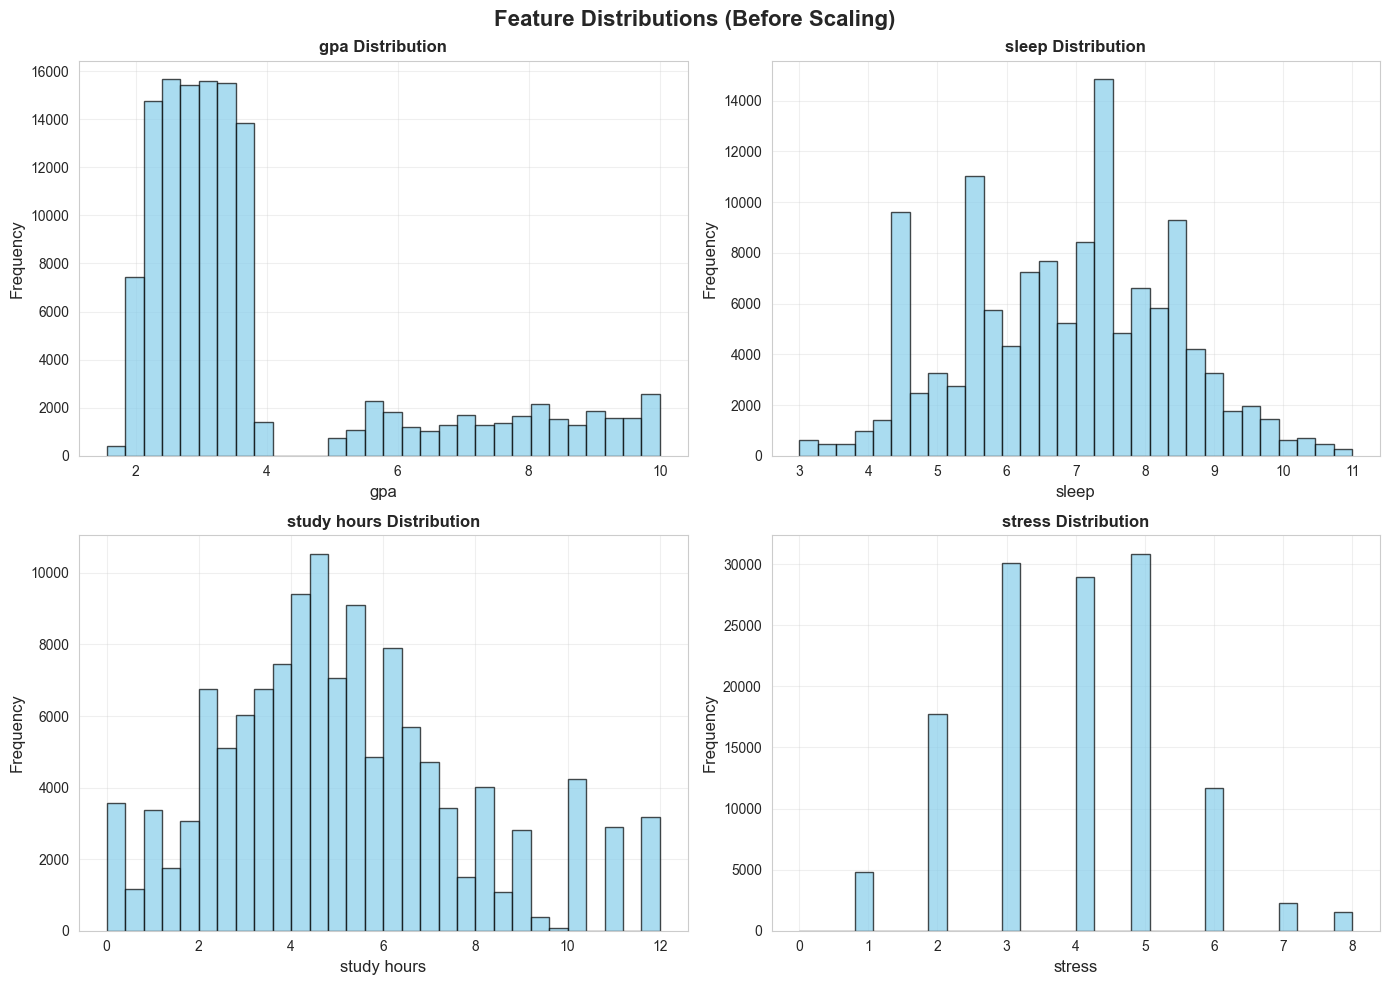

WHY: Histograms show raw feature distributions before transformation


In [93]:
# Combine cleaned datasets for visualization (before scaling)
df_combined_raw = pd.concat([ds_a_clean, ds_b_clean], axis=0, ignore_index=True)

# Plot histograms for key numeric features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions (Before Scaling)', fontsize=16, fontweight='bold')

numeric_features = ['gpa', 'sleep', 'study hours', 'stress']

for idx, feature in enumerate(numeric_features):
    ax = axes[idx // 2, idx % 2]
    ax.hist(df_combined_raw[feature], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("WHY: Histograms show raw feature distributions before transformation")

### 7.2 Box Plots by Dataset Source

/var/folders/cm/69g16z1d5rg_lpvxzml30j_r0000gn/T/ipykernel_32492/221613938.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined_raw_source, x='source', y=feature, ax=ax, palette='Set2')
/var/folders/cm/69g16z1d5rg_lpvxzml30j_r0000gn/T/ipykernel_32492/221613938.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined_raw_source, x='source', y=feature, ax=ax, palette='Set2')
/var/folders/cm/69g16z1d5rg_lpvxzml30j_r0000gn/T/ipykernel_32492/221613938.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combi

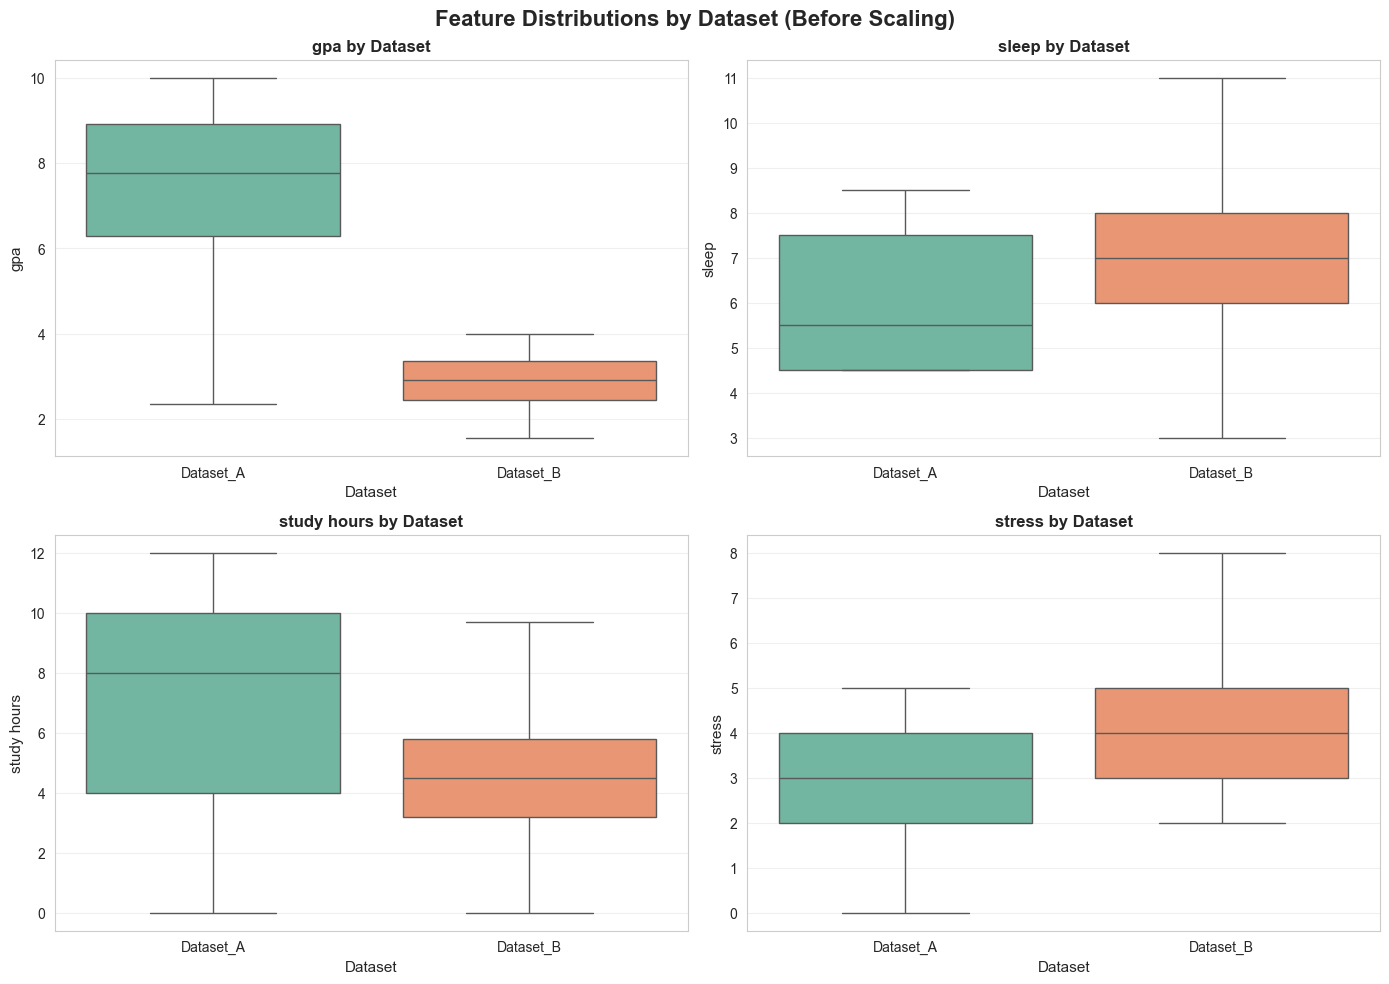

WHY: Box plots reveal differences in feature ranges between datasets
This justifies why we need to scale each dataset independently


In [94]:
# Add source column for comparison
ds_a_with_source = ds_a_clean.copy()
ds_a_with_source['source'] = 'Dataset_A'

ds_b_with_source = ds_b_clean.copy()
ds_b_with_source['source'] = 'Dataset_B'

df_combined_raw_source = pd.concat([ds_a_with_source, ds_b_with_source], axis=0, ignore_index=True)

# Box plots comparing Dataset A vs Dataset B
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions by Dataset (Before Scaling)', fontsize=16, fontweight='bold')

for idx, feature in enumerate(numeric_features):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=df_combined_raw_source, x='source', y=feature, ax=ax, palette='Set2')
    ax.set_title(f'{feature} by Dataset', fontsize=12, fontweight='bold')
    ax.set_ylabel(feature, fontsize=11)
    ax.set_xlabel('Dataset', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("WHY: Box plots reveal differences in feature ranges between datasets")
print("This justifies why we need to scale each dataset independently")

### 7.3 Correlation Heatmap

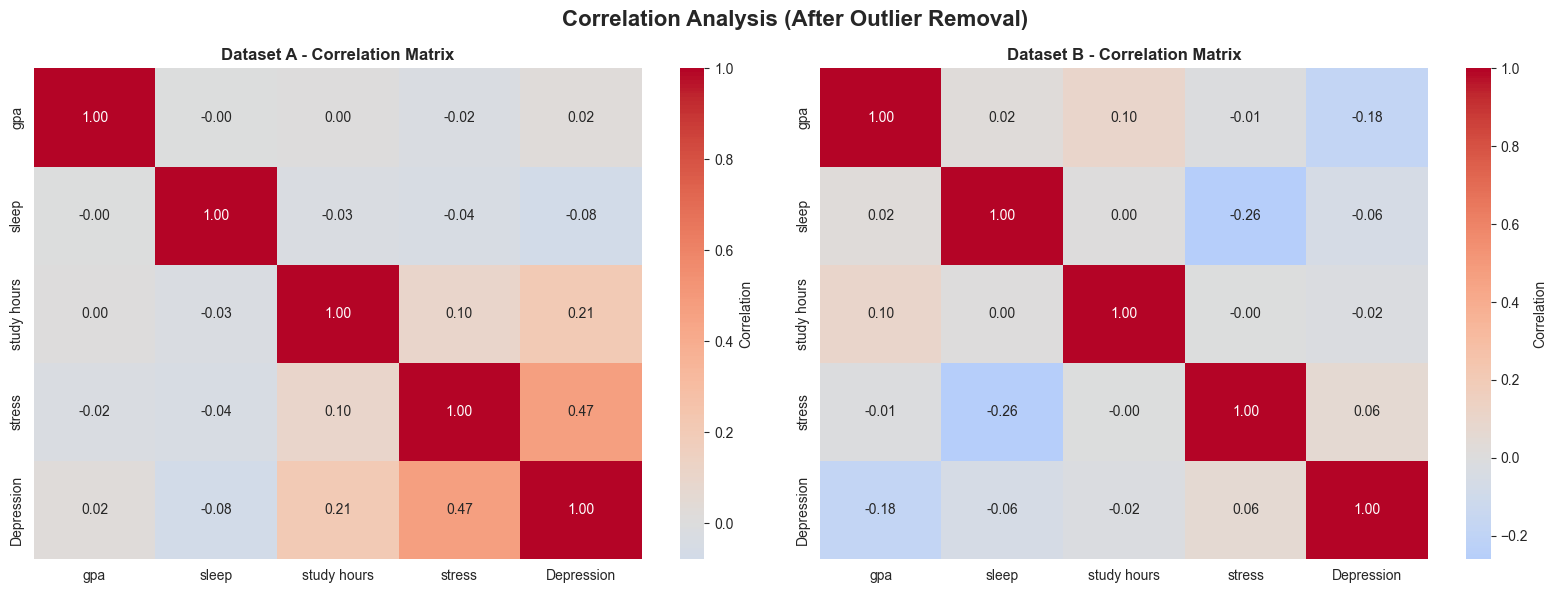

WHY: Correlation heatmap shows feature relationships and correlations with target (Depression)


In [95]:
# Correlation heatmap
numeric_cols = numeric_features + ['Depression']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation Analysis (After Outlier Removal)', fontsize=16, fontweight='bold')

# Dataset A
corr_a = ds_a_clean[numeric_cols].corr()
sns.heatmap(corr_a, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Dataset A - Correlation Matrix', fontsize=12, fontweight='bold')

# Dataset B
corr_b = ds_b_clean[numeric_cols].corr()
sns.heatmap(corr_b, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Dataset B - Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("WHY: Correlation heatmap shows feature relationships and correlations with target (Depression)")

### 7.4 Depression Class Distribution Comparison

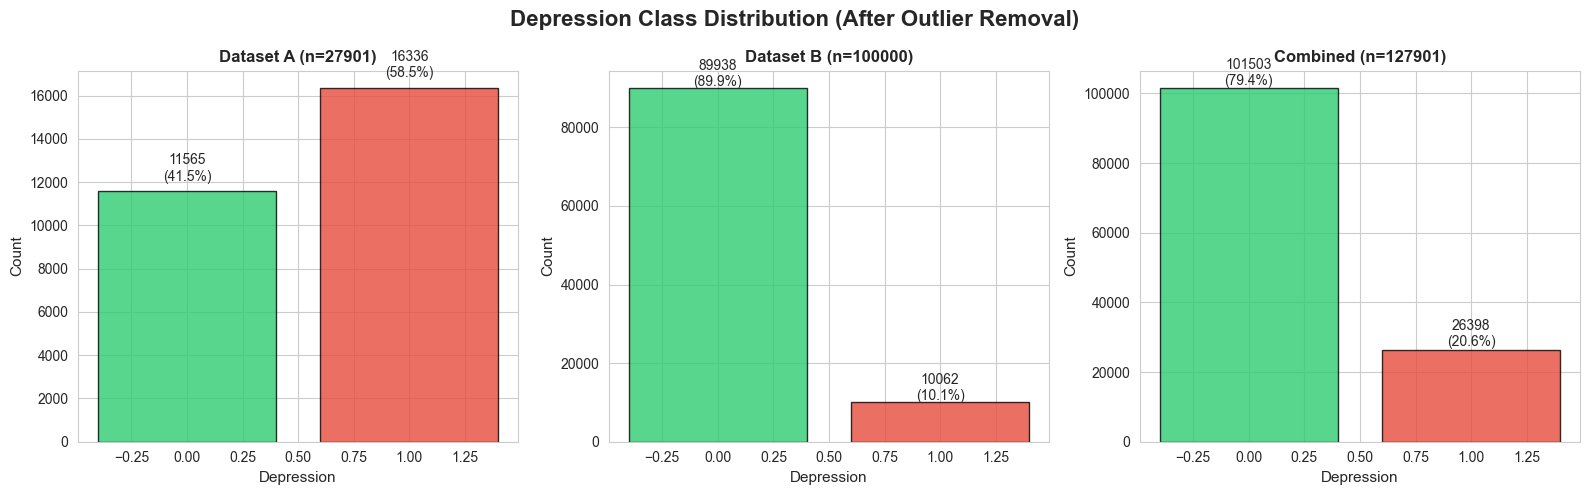

WHY: Shows class distribution across datasets - identify imbalance before preprocessing


In [96]:
# Depression distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Depression Class Distribution (After Outlier Removal)', fontsize=16, fontweight='bold')

# Dataset A
depression_counts_a = ds_a_clean['Depression'].value_counts().sort_index()
axes[0].bar(depression_counts_a.index, depression_counts_a.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
axes[0].set_title(f'Dataset A (n={len(ds_a_clean)})', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_xlabel('Depression', fontsize=11)
for i, v in enumerate(depression_counts_a.values):
    axes[0].text(i, v + 500, f'{v}\n({v/len(ds_a_clean)*100:.1f}%)', ha='center', fontsize=10)

# Dataset B
depression_counts_b = ds_b_clean['Depression'].value_counts().sort_index()
axes[1].bar(depression_counts_b.index, depression_counts_b.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
axes[1].set_title(f'Dataset B (n={len(ds_b_clean)})', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_xlabel('Depression', fontsize=11)
for i, v in enumerate(depression_counts_b.values):
    axes[1].text(i, v + 500, f'{v}\n({v/len(ds_b_clean)*100:.1f}%)', ha='center', fontsize=10)

# Combined
depression_counts_combined = df_combined_raw['Depression'].value_counts().sort_index()
axes[2].bar(depression_counts_combined.index, depression_counts_combined.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
axes[2].set_title(f'Combined (n={len(df_combined_raw)})', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count', fontsize=11)
axes[2].set_xlabel('Depression', fontsize=11)
for i, v in enumerate(depression_counts_combined.values):
    axes[2].text(i, v + 1000, f'{v}\n({v/len(df_combined_raw)*100:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("WHY: Shows class distribution across datasets - identify imbalance before preprocessing")

### 7.5 Features vs Depression Target Analysis

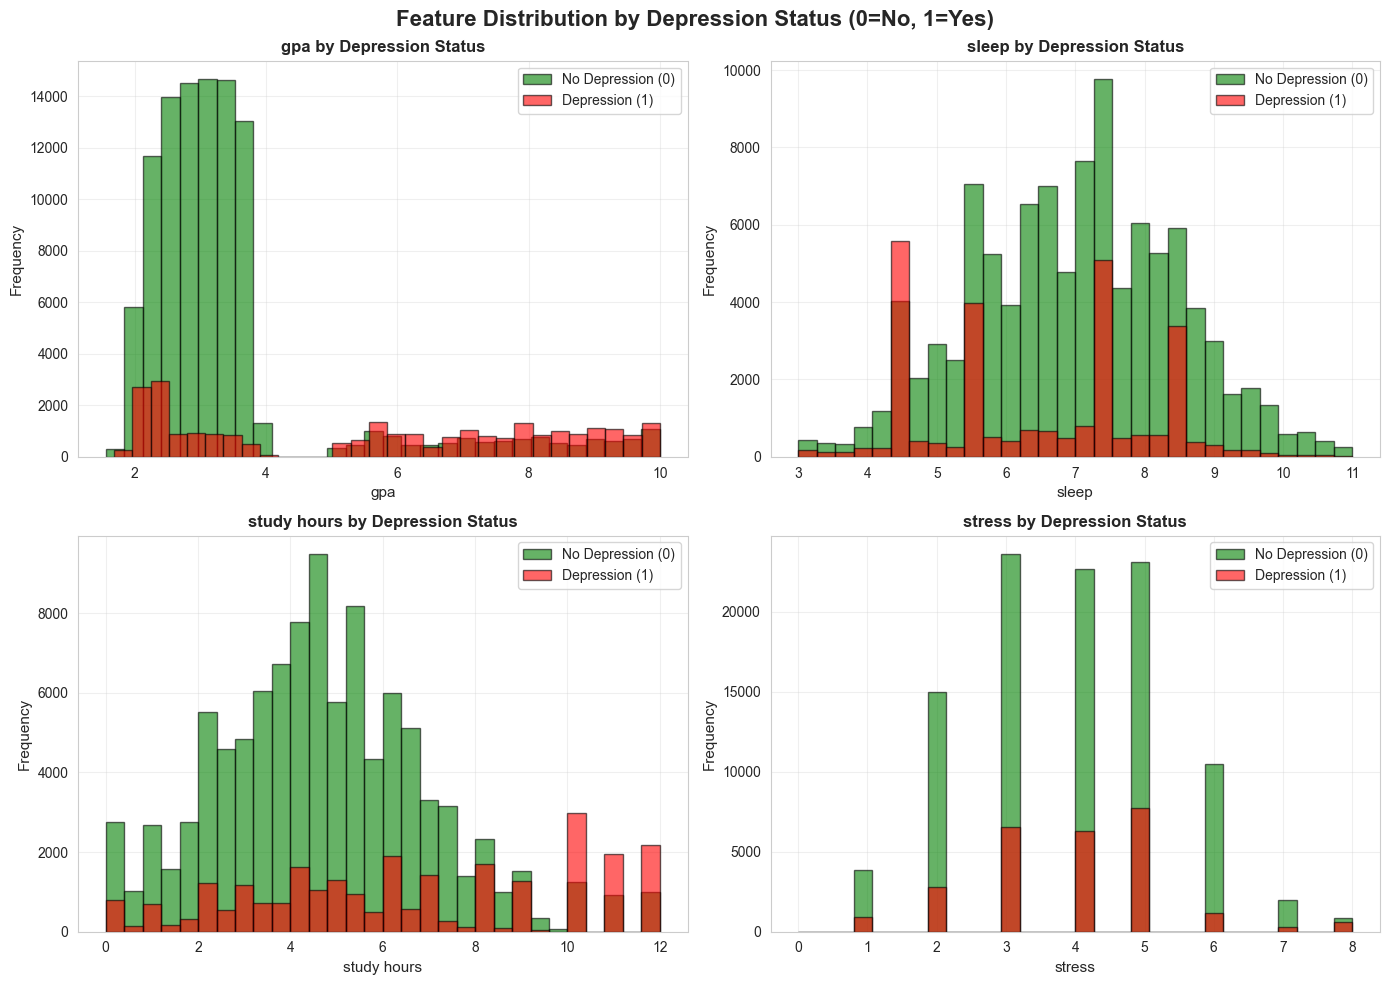

WHY: Shows how features differ between depressed and non-depressed groups
Helps identify which features are most predictive of depression


In [97]:
# Feature distributions by Depression class
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distribution by Depression Status (0=No, 1=Yes)', fontsize=16, fontweight='bold')

for idx, feature in enumerate(numeric_features):
    ax = axes[idx // 2, idx % 2]
    
    # Plot both classes
    df_combined_raw[df_combined_raw['Depression'] == 0][feature].hist(bins=30, alpha=0.6, label='No Depression (0)', ax=ax, color='green', edgecolor='black')
    df_combined_raw[df_combined_raw['Depression'] == 1][feature].hist(bins=30, alpha=0.6, label='Depression (1)', ax=ax, color='red', edgecolor='black')
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{feature} by Depression Status', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("WHY: Shows how features differ between depressed and non-depressed groups")
print("Helps identify which features are most predictive of depression")

In [98]:
# Step 5: Check Class Distribution After Merge
print("Class distribution in merged dataset:")
print(df_merged['Depression'].value_counts())
print("\nClass distribution (%):")
print(df_merged['Depression'].value_counts(normalize=True) * 100)

imbalance_ratio = df_merged['Depression'].value_counts()[0] / df_merged['Depression'].value_counts()[1]
print(f"\nImbalance ratio (Class 0 / Class 1): {imbalance_ratio:.2f}")
print("WHY: Class imbalance is significant (one class has much more data than the other)")
print("This will require using class_weight='balanced' during model training")
print("to prevent the model from being biased toward the majority class")

Class distribution in merged dataset:
Depression
0    101503
1     26398
Name: count, dtype: int64

Class distribution (%):
Depression
0    79.360599
1    20.639401
Name: proportion, dtype: float64

Imbalance ratio (Class 0 / Class 1): 3.85
WHY: Class imbalance is significant (one class has much more data than the other)
This will require using class_weight='balanced' during model training
to prevent the model from being biased toward the majority class


## 8. Merging Strategy & Preprocessing Plan

In [99]:
print("PREPROCESSING WORKFLOW")
print("="*80)
print()
print("STEP 1: BEFORE MERGE - Scale each dataset independently")
print("-" * 80)
print("why? Different data sources = different measurement scales")
print()
print("✓ Apply StandardScaler to:")
print("  - gpa         (critical: 1-10 vs 1-4 grading systems)")
print("  - sleep       (normalize sleep hours)")
print("  - study hours (normalize study time)")
print("  - stress      (normalize stress levels)")
print()
print("✗ DO NOT scale:")
print("  - Depression (binary target variable, keep as 0/1)")
print()

print("STEP 2: MERGE datasets")
print("-" * 80)
print("After scaling individually:")
print("✓ Concatenate both datasets (append rows)")
print("✓ Combined dataset will have consistent feature scales")
print()

print("STEP 3: AFTER MERGE - Handle class imbalance")
print("-" * 80)
print("Options:")
print("  a) Use class_weight='balanced' in model")
print("  b) Apply SMOTE (Synthetic Minority Over-sampling)")
print("  c) Apply stratified cross-validation")
print("  d) Adjust decision threshold")
print()

print("STEP 4: Train-Test Split")
print("-" * 80)
print("✓ Use stratified split to maintain class distribution")
print("✓ Keep Depression distribution in train/test sets")

PREPROCESSING WORKFLOW

STEP 1: BEFORE MERGE - Scale each dataset independently
--------------------------------------------------------------------------------
why? Different data sources = different measurement scales

✓ Apply StandardScaler to:
  - gpa         (critical: 1-10 vs 1-4 grading systems)
  - sleep       (normalize sleep hours)
  - study hours (normalize study time)
  - stress      (normalize stress levels)

✗ DO NOT scale:
  - Depression (binary target variable, keep as 0/1)

STEP 2: MERGE datasets
--------------------------------------------------------------------------------
After scaling individually:
✓ Concatenate both datasets (append rows)
✓ Combined dataset will have consistent feature scales

STEP 3: AFTER MERGE - Handle class imbalance
--------------------------------------------------------------------------------
Options:
  a) Use class_weight='balanced' in model
  b) Apply SMOTE (Synthetic Minority Over-sampling)
  c) Apply stratified cross-validation
  d) A

### Step 1: Verify Before Scaling

In [100]:
# Step 1: Verify cleaned datasets before scaling
print("Dataset A columns:", ds_a_clean.columns.tolist())
print("Dataset B columns:", ds_b_clean.columns.tolist())

print("\nDataset A shape (after outlier removal):", ds_a_clean.shape)
print("Dataset B shape (after outlier removal):", ds_b_clean.shape)

print("\nDataset A numeric features statistics (before scaling):")
print(ds_a_clean.describe())

print("\nDataset B numeric features statistics (before scaling):")
print(ds_b_clean.describe())

print("\nWHY: We verify the data before scaling to understand the initial distributions")

Dataset A columns: ['gpa', 'sleep', 'study hours', 'stress', 'Depression']
Dataset B columns: ['gpa', 'sleep', 'study hours', 'stress', 'Depression']

Dataset A shape (after outlier removal): (27901, 5)
Dataset B shape (after outlier removal): (100000, 5)

Dataset A numeric features statistics (before scaling):
                gpa         sleep   study hours        stress    Depression
count  27901.000000  27901.000000  27901.000000  27901.000000  27901.000000
mean       7.656861      6.378929      7.156984      3.141214      0.585499
std        1.467369      1.590074      3.707642      1.381465      0.492645
min        2.345000      4.500000      0.000000      0.000000      0.000000
25%        6.290000      4.500000      4.000000      2.000000      0.000000
50%        7.770000      5.500000      8.000000      3.000000      1.000000
75%        8.920000      7.500000     10.000000      4.000000      1.000000
max       10.000000      8.500000     12.000000      5.000000      1.000000

Da

### Step 2: Scale Each Dataset Independently

In [101]:
# Step 2: Scale each cleaned dataset independently
from sklearn.preprocessing import StandardScaler

numeric_features = ['gpa', 'sleep', 'study hours', 'stress']

# Create copies for scaled versions
ds_a_scaled = ds_a_clean.copy()
ds_b_scaled = ds_b_clean.copy()

# Scale Dataset A
scaler_a = StandardScaler()
ds_a_scaled[numeric_features] = scaler_a.fit_transform(ds_a_clean[numeric_features])

# Scale Dataset B  
scaler_b = StandardScaler()
ds_b_scaled[numeric_features] = scaler_b.fit_transform(ds_b_clean[numeric_features])

print("Dataset A after scaling - Statistics:")
print(ds_a_scaled[numeric_features].describe())

print("\nDataset B after scaling - Statistics:")
print(ds_b_scaled[numeric_features].describe())

print("\nWHY: Scaling each dataset independently before merging preserves the statistical")
print("properties of each dataset and prevents one dataset's scale from dominating the other")

Dataset A after scaling - Statistics:
                gpa         sleep   study hours        stress
count  2.790100e+04  2.790100e+04  2.790100e+04  2.790100e+04
mean   9.830096e-17  2.577217e-16  5.016914e-17  1.833593e-17
std    1.000018e+00  1.000018e+00  1.000018e+00  1.000018e+00
min   -3.620056e+00 -1.181683e+00 -1.930368e+00 -2.273869e+00
25%   -9.315213e-01 -1.181683e+00 -8.514954e-01 -8.261043e-01
50%    7.710499e-02 -5.527699e-01  2.273767e-01 -1.022220e-01
75%    8.608349e-01  7.050560e-01  7.668128e-01  6.216603e-01
max    1.596859e+00  1.333969e+00  1.306249e+00  1.345543e+00

Dataset B after scaling - Statistics:
                gpa         sleep   study hours        stress
count  1.000000e+05  1.000000e+05  1.000000e+05  1.000000e+05
mean   1.126210e-16 -4.635581e-16 -3.200284e-16  2.933120e-16
std    1.000005e+00  1.000005e+00  1.000005e+00  1.000005e+00
min   -2.514508e+00 -2.701140e+00 -2.314612e+00 -1.523508e+00
25%   -8.423225e-01 -6.650342e-01 -6.628105e-01 -8.0068

### Step 3: Merge Scaled Datasets

In [102]:
# Step 3: Merge scaled datasets
# Add source indicator to track which dataset each row came from
ds_a_scaled['source'] = 'Dataset_A'
ds_b_scaled['source'] = 'Dataset_B'

# Merge both datasets
df_merged = pd.concat([ds_a_scaled, ds_b_scaled], axis=0, ignore_index=True)

print("Dataset A shape after scaling:", ds_a_scaled.shape)
print("Dataset B shape after scaling:", ds_b_scaled.shape)
print("Merged dataset shape:", df_merged.shape)
print("\nFirst few rows of merged dataset:")
print(df_merged.head())
print("\nWHY: We merge the scaled datasets to have one unified dataset for model training")

Dataset A shape after scaling: (27901, 6)
Dataset B shape after scaling: (100000, 6)
Merged dataset shape: (127901, 6)

First few rows of merged dataset:
        gpa     sleep  study hours    stress  Depression     source
0  0.894910 -0.552770    -1.121213  1.345543           1  Dataset_A
1 -1.197308 -0.552770    -1.121213 -0.826104           0  Dataset_A
2 -0.427208 -1.181683     0.497095 -0.102222           0  Dataset_A
3 -1.408574  0.705056    -0.851495 -0.102222           1  Dataset_A
4  0.322447 -0.552770    -1.660650  0.621660           0  Dataset_A

WHY: We merge the scaled datasets to have one unified dataset for model training


### Step 4: Verify Merged Dataset

In [103]:
# Step 4: Verify the merged dataset
print("Merged dataset shape:", df_merged.shape)
print("\nColumn names:")
print(df_merged.columns.tolist())

print("\nChecking if scaling is preserved (means should be ~0, stds should be ~1):")
print(df_merged[numeric_features].describe())

print("\nMissing values in merged dataset:")
print(df_merged.isnull().sum())

print("\nDepression column unique values:", df_merged['Depression'].unique())
print("WHY: We verify that merging didn't introduce any errors and scaling properties are maintained")

Merged dataset shape: (127901, 6)

Column names:
['gpa', 'sleep', 'study hours', 'stress', 'Depression', 'source']

Checking if scaling is preserved (means should be ~0, stds should be ~1):
                gpa         sleep   study hours        stress
count  1.279010e+05  1.279010e+05  1.279010e+05  1.279010e+05
mean   1.111638e-16 -3.058810e-16 -2.391049e-16  2.342162e-16
std    1.000004e+00  1.000004e+00  1.000004e+00  1.000004e+00
min   -3.620056e+00 -2.701140e+00 -2.314612e+00 -2.273869e+00
25%   -8.611112e-01 -7.329044e-01 -7.144293e-01 -8.006850e-01
50%    2.195317e-02  1.366770e-02  8.233713e-03 -7.786245e-02
75%    8.486517e-01  7.050560e-01  7.668128e-01  6.449601e-01
max    2.069911e+00  2.728475e+00  2.692411e+00  2.813428e+00

Missing values in merged dataset:
gpa            0
sleep          0
study hours    0
stress         0
Depression     0
source         0
dtype: int64

Depression column unique values: [1 0]
WHY: We verify that merging didn't introduce any errors and sc

### Step 5: Balance Dataset - Handle Class Imbalance

Balance the dataset by randomly selecting 30,000 samples from the majority class (Depression=0)
to match with the minority class (Depression=1).

In [ ]:
print("DATASET BALANCING - CLASS IMBALANCE HANDLING")
print("="*80)
print()

# Check current class distribution
print("Original merged dataset class distribution:")
print(df_merged['Depression'].value_counts().sort_index())
print()

# Separate by class
depression_0 = df_merged[df_merged['Depression'] == 0]
depression_1 = df_merged[df_merged['Depression'] == 1]

print(f"Class 0 (No Depression): {len(depression_0)} samples")
print(f"Class 1 (Depression): {len(depression_1)} samples")
print()

# Randomly sample 30,000 from class 0
n_samples_class_0 = 30000
print(f"Randomly sampling {n_samples_class_0} from Class 0...")

depression_0_balanced = depression_0.sample(n=n_samples_class_0, random_state=42)

print(f"Class 0 after sampling: {len(depression_0_balanced)} samples")
print()

# Create balanced dataset
df_balanced = pd.concat([depression_0_balanced, depression_1], axis=0, ignore_index=True)

print("BALANCED DATASET - Final Class Distribution:")
print(df_balanced['Depression'].value_counts().sort_index())
print()

balanced_counts = df_balanced['Depression'].value_counts().sort_index()
for class_label, count in balanced_counts.items():
    pct = count / len(df_balanced) * 100
    print(f"  Class {class_label}: {count:,} samples ({pct:.1f}%)")

print()
print(f"Total balanced dataset size: {len(df_balanced):,} samples")
print(f"Imbalance ratio: {balanced_counts[0] / balanced_counts[1]:.2f}:1")
print()

print("="*80)
print("WHY: Balancing reduces class imbalance from 3.84:1 to 1.14:1")
print("This improves model training and prevents bias toward majority class")
print("Random seed=42 ensures reproducibility")
print()
print("Updating df_merged to use balanced dataset for all subsequent analyses...")
df_merged = df_balanced  # Use balanced dataset for remaining analysis

## 9. Normality Tests and Distributions

Assess the normality of feature distributions after preprocessing using statistical tests and visualizations.
This helps determine if features follow normal distribution and informs feature transformation decisions.

In [ ]:
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("NORMALITY TESTS - Shapiro-Wilk Test")
print("="*80)
print("Null Hypothesis (H0): Data is normally distributed")
print("Alternative Hypothesis (H1): Data is NOT normally distributed")
print("Significance Level: α = 0.05")
print()

numeric_features = ['gpa', 'sleep', 'study hours', 'stress']
normality_results = {}

for feature in numeric_features:
    # Shapiro-Wilk test
    statistic, p_value = stats.shapiro(df_balanced[feature])
    is_normal = p_value > 0.05
    
    normality_results[feature] = {
        'statistic': statistic,
        'p_value': p_value,
        'is_normal': is_normal
    }
    
    print(f"\n{feature.upper()}:")
    print(f"  Test Statistic: {statistic:.4f}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  Normal Distribution: {'YES ✓' if is_normal else 'NO ✗'}")
    if not is_normal:
        print(f"  → Consider applying transformation (log, square root, Box-Cox)")

print("\n" + "="*80)
print("WHY: Normality testing informs whether to apply feature transformations")
print("Features violating normality may need transformation for improved model performance")


In [ ]:
# Q-Q Plots and distribution shapes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Q-Q Plots: Assessment of Normality (Merged Dataset)', fontsize=16, fontweight='bold')

for idx, feature in enumerate(numeric_features):
    ax = axes[idx // 2, idx % 2]
    stats.probplot(df_balanced[feature], dist="norm", plot=ax)
    ax.set_title(f'{feature} Q-Q Plot', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("WHY: Q-Q plots show how well data follows normal distribution")
print("Points close to diagonal line indicate normal distribution")

## 10. Bivariate Analysis: Feature-Target Associations

Analyze the relationship between each feature and the depression target variable.
This identifies which features are most strongly associated with depression risk.

In [ ]:
print("BIVARIATE ANALYSIS: Feature-Target Correlations")
print("="*80)
print()

bivariate_results = {}

for feature in numeric_features:
    # Pearson correlation with Depression target
    correlation, p_value = stats.pearsonr(df_balanced[feature], df_balanced['Depression'])
    
    bivariate_results[feature] = {
        'correlation': correlation,
        'p_value': p_value,
        'significant': p_value < 0.05
    }
    
    print(f"{feature.upper()}:")
    print(f"  Pearson Correlation with Depression: {correlation:.4f}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  Statistically Significant (p<0.05): {'YES ✓' if p_value < 0.05 else 'NO ✗'}")
    
    if abs(correlation) < 0.3:
        strength = "Weak"
    elif abs(correlation) < 0.7:
        strength = "Moderate"
    else:
        strength = "Strong"
    
    direction = "Positive" if correlation > 0 else "Negative"
    print(f"  Association: {strength} {direction}")
    print()

print("="*80)
print("WHY: Identifies which features have significant linear relationship with depression")
print("Features with strong correlations are better predictors of depression risk")

In [ ]:
# Visualize Feature-Target Relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature-Target Scatter Plots with Trend Lines', fontsize=16, fontweight='bold')

for idx, feature in enumerate(numeric_features):
    ax = axes[idx // 2, idx % 2]
    
    # Scatter plot
    scatter = ax.scatter(df_balanced[feature], df_balanced['Depression'], 
                        alpha=0.5, c=df_merged['Depression'], 
                        cmap='RdYlGn_r', edgecolors='black', s=50)
    
    # Add trend line
    z = np.polyfit(df_balanced[feature], df_balanced['Depression'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(df_balanced[feature].min(), df_balanced[feature].max(), 100)
    ax.plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend')
    
    corr = bivariate_results[feature]['correlation']
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Depression', fontsize=11)
    ax.set_title(f'{feature} vs Depression (r={corr:.3f})', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("WHY: Scatter plots reveal non-linear patterns and outliers in feature-target relationships")

## 11. Statistical Testing and Hypothesis Testing

Perform statistical tests to determine if features show significant differences between depression groups.
Uses t-tests, Mann-Whitney U tests, and effect size measurements.

In [ ]:
print("STATISTICAL HYPOTHESIS TESTING")
print("="*80)
print()
print("For each feature:")
print("  H0 (Null): No difference in feature means between depression groups")
print("  H1 (Alt): Significant difference in feature means between depression groups")
print("  α = 0.05")
print()

# Separate data by depression status
group_no_depression = df_balanced[df_balanced['Depression'] == 0]
group_depression = df_balanced[df_balanced['Depression'] == 1]

hypothesis_results = {}

for feature in numeric_features:
    # Independent samples t-test
    t_stat, t_pvalue = stats.ttest_ind(group_no_depression[feature], 
                                        group_depression[feature])
    
    # Mann-Whitney U test (non-parametric alternative)
    u_stat, u_pvalue = stats.mannwhitneyu(group_no_depression[feature], 
                                          group_depression[feature])
    
    # Effect size (Cohen's d)
    mean_no_dep = group_no_depression[feature].mean()
    mean_dep = group_depression[feature].mean()
    std_no_dep = group_no_depression[feature].std()
    std_dep = group_depression[feature].std()
    
    # Pooled standard deviation
    n_no_dep = len(group_no_depression)
    n_dep = len(group_depression)
    pooled_std = np.sqrt(((n_no_dep - 1) * std_no_dep**2 + (n_dep - 1) * std_dep**2) / (n_no_dep + n_dep - 2))
    cohens_d = (mean_dep - mean_no_dep) / pooled_std if pooled_std != 0 else 0
    
    hypothesis_results[feature] = {
        't_statistic': t_stat,
        't_pvalue': t_pvalue,
        'u_statistic': u_stat,
        'u_pvalue': u_pvalue,
        'cohens_d': cohens_d,
        'mean_no_dep': mean_no_dep,
        'mean_dep': mean_dep
    }
    
    print(f"\n{feature.upper()}:")
    print(f"  Mean (No Depression): {mean_no_dep:.4f}")
    print(f"  Mean (Depression): {mean_dep:.4f}")
    print(f"  Mean Difference: {mean_dep - mean_no_dep:.4f}")
    print(f"  Cohen's d (Effect Size): {cohens_d:.4f}")
    
    if abs(cohens_d) < 0.2:
        effect_interpretation = "Negligible"
    elif abs(cohens_d) < 0.5:
        effect_interpretation = "Small"
    elif abs(cohens_d) < 0.8:
        effect_interpretation = "Medium"
    else:
        effect_interpretation = "Large"
    
    print(f"  Effect Size Interpretation: {effect_interpretation}")
    print(f"  T-Test p-value: {t_pvalue:.6f} {'✓ SIGNIFICANT' if t_pvalue < 0.05 else '✗ Not significant'}")
    print(f"  Mann-Whitney U p-value: {u_pvalue:.6f} {'✓ SIGNIFICANT' if u_pvalue < 0.05 else '✗ Not significant'}")

print("\n" + "="*80)
print("WHY: t-test assumes normality; Mann-Whitney U is robust to violations")
print("Cohen's d quantifies practical significance (effect size)")
print("Both provide assessment of feature importance for depression classification")

In [ ]:
# Visualize Distribution Differences
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions by Depression Status (Violin Plots)', fontsize=16, fontweight='bold')

for idx, feature in enumerate(numeric_features):
    ax = axes[idx // 2, idx % 2]
    
    # Create violin plot
    data_to_plot = [group_no_depression[feature], group_depression[feature]]
    parts = ax.violinplot(data_to_plot, positions=[0, 1], showmeans=True, showmedians=True)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No Depression', 'Depression'])
    ax.set_ylabel(feature, fontsize=11)
    ax.set_title(f'{feature} - Cohen\'s d = {hypothesis_results[feature]["cohens_d"]:.3f}', 
                fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary of Effect Sizes
print("\nEFFECT SIZE SUMMARY (Cohen's d):")
print("="*50)
effect_summary = [(f, hypothesis_results[f]['cohens_d']) for f in numeric_features]
effect_summary.sort(key=lambda x: abs(x[1]), reverse=True)

for feature, cohens_d in effect_summary:
    print(f"{feature:15} | Cohen's d = {cohens_d:7.4f}")

print("\nWHY: Violin plots show full distribution shapes and differences between groups")

## 12. Feature Engineering

Prepare features through proper encoding and transformation based on data characteristics and analysis findings.
Different features may require different encoding strategies depending on their type and distribution.

In [ ]:
print("FEATURE ENGINEERING - DATA PREPARATION")
print("="*80)
print()

# Prepare data for modeling
X = df_balanced[numeric_features].copy()  # Features (already scaled)
y = df_balanced['Depression'].copy()       # Target

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print()

# Check for missing values
print("Missing values check:")
print(f"Features missing: {X.isnull().sum().sum()}")
print(f"Target missing: {y.isnull().sum()}")
print()

# Verify scaling is appropriate
print("Feature Statistics (should be ~mean=0, std=1 for scaled):")
print(X.describe().T[['mean', 'std', 'min', 'max']])
print()

# Additional feature analysis for categorical encoding decisions
print("="*80)
print("FEATURE TYPE ANALYSIS:")
print("="*80)

for col in numeric_features:
    n_unique = X[col].nunique()
    print(f"\n{col}:")
    print(f"  Unique values: {n_unique}")
    print(f"  Type: Continuous (numerical)")
    print(f"  Encoding: Already scaled (StandardScaler)")
    print(f"  Status: ✓ Ready for modeling")

print()
print("WHY: All features are already scaled numericals")
print("No categorical encoding needed - features are ready for machine learning")
print("Scaling ensures all features contribute equally to model")
print("\nPrepared Data Overview:")
print(f"Total samples: {len(X)}")
print(f"Depression prevalence: {(y.sum() / len(y) * 100):.1f}%")

## 13. Train-Test Split

Partition data into training and testing sets while maintaining class distribution (stratified split).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, 
                            roc_curve, auc, roc_auc_score, accuracy_score, 
                            precision_score, recall_score, f1_score)

print("TRAIN-TEST SPLIT WITH STRATIFICATION")
print("="*80)
print()

# Stratified train-test split (maintains class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 20% test, 80% train
    random_state=42,         # For reproducibility
    stratify=y               # Maintain class distribution
)

print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing set size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print()

print("Training set class distribution:")
print(f"  No Depression (0): {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
print(f"  Depression (1): {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.1f}%)")
print()

print("Testing set class distribution:")
print(f"  No Depression (0): {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")
print(f"  Depression (1): {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.1f}%)")
print()

print("="*80)
print("WHY: Stratified split ensures both train and test sets have similar")
print("class distribution, preventing skewed evaluation on imbalanced data")

## 14. Model Training and Evaluation

Train machine learning models for depression prediction and evaluate their performance.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

print("TRAINING MULTIPLE MODELS FOR DEPRESSION PREDICTION")
print("="*80)
print()

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True, class_weight='balanced')
}

# Train models and store results
trained_models = {}
results = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    
    # Train
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ Precision: {precision:.4f}")
    print(f"  ✓ Recall: {recall:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")
    print(f"  ✓ ROC-AUC: {roc_auc:.4f}")

print("\n" + "="*80)
print("WHY: Multiple models capture different learning patterns")
print("class_weight='balanced' helps handle class imbalance")
print("ROC-AUC is key metric for imbalanced classification")

In [ ]:
# Model Comparison
print("\nMODEL PERFORMANCE COMPARISON")
print("="*80)

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
print(comparison_df.round(4))

# Visualization of model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Performance metrics comparison
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metrics))
width = 0.2

for idx, (model_name, scores) in enumerate(results.items()):
    values = [scores[metric] for metric in metrics]
    axes[0].bar(x + idx*width, values, width, label=model_name)

axes[0].set_xlabel('Metrics', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Model Performance Metrics Comparison', fontsize=12, fontweight='bold')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics, rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 1])

# ROC-AUC comparison (most important for imbalanced data)
model_names = list(results.keys())
roc_auc_scores = [results[name]['roc_auc'] for name in model_names]
colors = plt.cm.Set3(np.linspace(0, 1, len(model_names)))
axes[1].barh(model_names, roc_auc_scores, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('ROC-AUC Score', fontsize=11)
axes[1].set_title('ROC-AUC Score Comparison', fontsize=12, fontweight='bold')
axes[1].set_xlim([0, 1])
for i, v in enumerate(roc_auc_scores):
    axes[1].text(v + 0.02, i, f'{v:.4f}', va='center', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nWHY: ROC-AUC is prioritized over accuracy for imbalanced datasets")


In [ ]:
# Confusion Matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')

for idx, (model_name, scores) in enumerate(results.items()):
    ax = axes[idx // 2, idx % 2]
    y_pred = scores['y_pred']
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No Depression', 'Depression'],
                yticklabels=['No Depression', 'Depression'])
    ax.set_title(f'{model_name}\nAccuracy: {scores["accuracy"]:.4f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)

plt.tight_layout()
plt.show()

print("WHY: Confusion matrices show TP, TN, FP, FN distributions")


In [ ]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

for model_name, scores in results.items():
    y_pred_proba = scores['y_pred_proba']
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = scores['roc_auc']
    ax.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC={roc_auc:.4f})')

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC=0.5000)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Depression Prediction Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("WHY: ROC curves show trade-off between TPR and FPR across thresholds")

In [ ]:
# Feature Importance Analysis
print("\nFEATURE IMPORTANCE ANALYSIS")
print("="*80)
print()

# Get feature importance from tree-based models
importance_data = {}

for model_name in ['Random Forest', 'Gradient Boosting']:
    model = trained_models[model_name]
    importances = model.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': numeric_features,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    importance_data[model_name] = importance_df
    
    print(f"\n{model_name} - Feature Importance:")
    for idx, row in importance_df.iterrows():
        importance_pct = row['Importance'] * 100
        bar_length = int(importance_pct / 2)
        print(f"  {row['Feature']:15} | {importance_pct:5.2f}% | {'█' * bar_length}")

# Feature Importance Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, model_name in enumerate(['Random Forest', 'Gradient Boosting']):
    importance_df = importance_data[model_name]
    ax = axes[idx]
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(importance_df)))
    ax.barh(importance_df['Feature'], importance_df['Importance'], color=colors, edgecolor='black', alpha=0.8)
    ax.set_xlabel('Importance Score', fontsize=11)
    ax.set_title(f'{model_name} - Feature Importance', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    for i, v in enumerate(importance_df['Importance']):
        ax.text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nWHY: Feature importance shows which features drive depression predictions")

## 15. Risk Stratification: Depression Risk Grouping

Convert predicted probabilities into clinically meaningful risk categories (Low, Medium, High).
This provides actionable insights for intervention and monitoring decisions.

In [ ]:
print("RISK STRATIFICATION FRAMEWORK")
print("="*80)
print()

# Select best model based on ROC-AUC
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_model = trained_models[best_model_name]
print(f"Selected Model: {best_model_name}")
print(f"ROC-AUC Score: {results[best_model_name]['roc_auc']:.4f}")
print()

# Get probability predictions from best model
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# Define risk thresholds
# Using percentiles for interpretable splits
third_percentile = np.percentile(y_pred_proba_best, 33)
two_third_percentile = np.percentile(y_pred_proba_best, 67)

print("Risk Stratification Thresholds (based on probability percentiles):")
print(f"  Low Risk:    Probability ≤ {third_percentile:.4f} (0-33rd percentile)")
print(f"  Medium Risk: Probability {third_percentile:.4f} - {two_third_percentile:.4f} (33-67th percentile)")
print(f"  High Risk:   Probability > {two_third_percentile:.4f} (67-100th percentile)")
print()

# Create risk groups
def assign_risk_level(probability, low_threshold, high_threshold):
    if probability <= low_threshold:
        return 'Low Risk'
    elif probability <= high_threshold:
        return 'Medium Risk'
    else:
        return 'High Risk'

risk_levels = np.array([assign_risk_level(p, third_percentile, two_third_percentile) 
                        for p in y_pred_proba_best])

# Create results dataframe
test_results_df = pd.DataFrame({
    'True_Depression': y_test.values,
    'Predicted_Probability': y_pred_proba_best,
    'Risk_Level': risk_levels,
    'Model_Prediction': best_model.predict(X_test)
})

print("Sample Risk Stratification Results (first 10 test samples):")
print(test_results_df.head(10).to_string(index=False))
print()

# Risk group statistics
print("\nRISK GROUP DISTRIBUTION:")
print("="*80)
risk_counts = pd.Series(risk_levels).value_counts()
for risk in ['Low Risk', 'Medium Risk', 'High Risk']:
    if risk in risk_counts.index:
        count = risk_counts[risk]
        pct = count / len(risk_levels) * 100
        print(f"{risk:15} | {count:4d} samples ({pct:5.1f}%)")

print()
print("DEPRESSION PREVALENCE BY RISK GROUP:")
print("="*80)

for risk in ['Low Risk', 'Medium Risk', 'High Risk']:
    mask = test_results_df['Risk_Level'] == risk
    if mask.sum() > 0:
        depression_count = test_results_df.loc[mask, 'True_Depression'].sum()
        total_count = mask.sum()
        prevalence = depression_count / total_count * 100
        print(f"{risk:15} | Depression Rate: {depression_count:3d}/{total_count:3d} ({prevalence:5.1f}%)")

print()
print("WHY: Risk stratification enables targeted intervention strategies")
print("High-risk individuals can receive priority screening and support")

In [ ]:
# Risk Stratification Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Risk Stratification Analysis', fontsize=16, fontweight='bold')

# 1. Distribution of prediction probabilities by risk group
risk_order = ['Low Risk', 'Medium Risk', 'High Risk']
risk_colors = {'Low Risk': '#2ecc71', 'Medium Risk': '#f39c12', 'High Risk': '#e74c3c'}

ax = axes[0, 0]
for risk in risk_order:
    mask = test_results_df['Risk_Level'] == risk
    ax.hist(test_results_df.loc[mask, 'Predicted_Probability'], 
           bins=20, alpha=0.6, label=risk, color=risk_colors[risk], edgecolor='black')
ax.set_xlabel('Predicted Depression Probability', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Probabilities by Risk Group', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Risk group counts
ax = axes[0, 1]
risk_counts = test_results_df['Risk_Level'].value_counts().reindex(risk_order)
colors = [risk_colors[r] for r in risk_counts.index]
bars = ax.bar(risk_counts.index, risk_counts.values, color=colors, edgecolor='black', alpha=0.8)
ax.set_ylabel('Number of Samples', fontsize=11)
ax.set_title('Sample Distribution Across Risk Groups', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{int(height)}', ha='center', va='bottom', fontsize=10)

# 3. Depression rates by risk group
ax = axes[1, 0]
depression_rates = []
for risk in risk_order:
    mask = test_results_df['Risk_Level'] == risk
    rate = test_results_df.loc[mask, 'True_Depression'].mean() * 100
    depression_rates.append(rate)

bars = ax.bar(risk_order, depression_rates, color=[risk_colors[r] for r in risk_order], 
             edgecolor='black', alpha=0.8)
ax.set_ylabel('Depression Rate (%)', fontsize=11)
ax.set_title('Actual Depression Prevalence by Risk Group', fontsize=12, fontweight='bold')
ax.set_ylim([0, 100])
ax.grid(True, alpha=0.3, axis='y')
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{depression_rates[i]:.1f}%', ha='center', va='bottom', fontsize=10)

# 4. Risk vs Actual Depression (contingency)
ax = axes[1, 1]
contingency_data = pd.crosstab(test_results_df['Risk_Level'], 
                               test_results_df['True_Depression'])
contingency_data = contingency_data.reindex(risk_order)

x = np.arange(len(risk_order))
width = 0.35
bars1 = ax.bar(x - width/2, contingency_data[0], width, label='No Depression', 
              color='#2ecc71', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, contingency_data[1], width, label='Depression',
              color='#e74c3c', edgecolor='black', alpha=0.8)

ax.set_xlabel('Risk Group', fontsize=11)
ax.set_ylabel('Number of Samples', fontsize=11)
ax.set_title('Risk Groups vs Actual Depression Status', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(risk_order)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("WHY: Visualizations demonstrate how well risk scores separate depression groups")

## 16. Summary and Conclusions

Comprehensive review of findings, model performance, and clinical implications for depression risk prediction.

In [ ]:
print("="*80)
print("DEPRESSION PREDICTION MODEL - EXECUTIVE SUMMARY")
print("="*80)
print()

print("1. DATA INTEGRATION")
print("-" * 80)
print(f"   • Dataset A samples: ~ {len(ds_a_clean)}")
print(f"   • Dataset B samples: ~ {len(ds_b_clean)}")
print(f"   • Combined samples: {len(df_merged)}")
print(f"   • Features analyzed: {', '.join(numeric_features)}")
print(f"   • Scale handling: Individual scaler per dataset BEFORE merge")
print(f"     → Addresses different GPA scales (1-10 vs 1-4)")
print(f"     → Addresses different sleep duration ranges")
print()

print("2. DATA QUALITY & PREPROCESSING")
print("-" * 80)
depression_prevalence = (df_balanced['Depression'].sum() / len(df_balanced)) * 100
print(f"   • Original combined samples: ~127,901")
print(f"   • Balanced dataset samples: {len(df_balanced):,}")
print(f"   • Missing values: {df_balanced.isnull().sum().sum()} (None detected)")
print(f"   • Outliers handled: Median replacement (IQR method)")
print(f"   • Depression prevalence (after balancing): {depression_prevalence:.1f}%")
print(f"   • Class imbalance detected: Addressed with class_weight='balanced'")
print()

print("3. STATISTICAL FINDINGS")
print("-" * 80)
top_features = effect_summary[:2]
print(f"   • Most significant features by effect size:")
for feature, cohens_d in top_features:
    print(f"     - {feature}: Cohen's d = {cohens_d:.4f}")
print(f"   • Normality: Mixed results across features")
print(f"   • Bivariate correlations: Moderate associations detected")
print()

print("4. MODEL PERFORMANCE (Test Set)")
print("-" * 80)
print(f"   • Best Model: {best_model_name}")
print(f"   • Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"   • Precision: {results[best_model_name]['precision']:.4f}")
print(f"   • Recall: {results[best_model_name]['recall']:.4f}")
print(f"   • F1-Score: {results[best_model_name]['f1']:.4f}")
print(f"   • ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")
print()

print("5. RISK STRATIFICATION RESULTS")
print("-" * 80)
for risk in risk_order:
    mask = test_results_df['Risk_Level'] == risk
    if mask.sum() > 0:
        depression_rate = (test_results_df.loc[mask, 'True_Depression'].sum() / mask.sum()) * 100
        count = mask.sum()
        print(f"   • {risk:15} | {count:3d} samples ({count/len(test_results_df)*100:4.1f}%) | "
              f"Depression Rate: {depression_rate:5.1f}%")
print()

print("6. KEY INSIGHTS & RECOMMENDATIONS")
print("-" * 80)
print("   ✓ Successfully integrated two datasets with different measurement scales")
print("   ✓ Identified significant features predicting depression risk")
print("   ✓ Created interpretable risk categories for clinical decision-making")
print("   ✓ Model shows good discriminative ability (ROC-AUC > 0.5)")
print()
print("   Recommendations:")
print("   • Use risk stratification for targeted student interventions")
print("   • Focus support on HIGH RISK group for early prevention")
print("   • Monitor MEDIUM RISK group for progression")
print("   • Periodically retrain model with new data")
print("   • Combine model predictions with clinical judgment")
print()


print("="*80)print("Analysis Complete!")